In [1]:
# =====================================================
# STEP 1: IMPORT LIBRARIES
# =====================================================
# Libraries are tools that help us perform data analysis
# and machine learning tasks.

import pandas as pd          # Used for working with datasets (tables)
import numpy as np           # Used for numerical calculations
import matplotlib.pyplot as plt   # Used for creating graphs

# Machine learning tools from scikit-learn
from sklearn.model_selection import train_test_split   # Splits dataset into training and testing
from sklearn.preprocessing import LabelEncoder         # Converts text data into numbers
from sklearn.linear_model import LinearRegression      # Machine learning model used for prediction
from sklearn.metrics import mean_squared_error, r2_score   # Used to evaluate model performance

In [4]:
# =====================================================
# STEP 2: LOAD DATASET
# =====================================================
# Read the student performance dataset from CSV file.

data = pd.read_csv("StudentPerformanceFactors.csv")

# Display first 5 rows to understand the dataset structure
print("First 5 rows of dataset:")
print(data.head().T)

First 5 rows of dataset:
                                      0         1             2            3  \
Id                                    1         2             3            4   
Hours_Studied                        23        19            24           29   
Attendance                           84        64            98           89   
Parental_Involvement                Low       Low        Medium          Low   
Access_to_Resources                High    Medium        Medium       Medium   
Extracurricular_Activities           No        No           Yes          Yes   
Sleep_Hours                           7         8             7            8   
Previous_Scores                      73        59            91           98   
Motivation_Level                    Low       Low        Medium       Medium   
Internet_Access                     Yes       Yes           Yes          Yes   
Tutoring_Sessions                     0         2             2            1   
Family_Income  

In [5]:
# =====================================================
# STEP 3: DATA UNDERSTANDING
# =====================================================
# Check basic information about the dataset.

# Check number of rows and columns
print("Dataset shape:")
print(data.shape)

# Check column names and data types
print("\nDataset information:")
print(data.info())

# Statistical summary of numeric columns
print("\nStatistical summary:")
print(data.describe())

# Check missing values in each column
print("\nMissing values in dataset:")
print(data.isnull().sum())

Dataset shape:
(6607, 20)

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Id                          6607 non-null   int64
 1   Hours_Studied               6607 non-null   int64
 2   Attendance                  6607 non-null   int64
 3   Parental_Involvement        6607 non-null   str  
 4   Access_to_Resources         6607 non-null   str  
 5   Extracurricular_Activities  6607 non-null   str  
 6   Sleep_Hours                 6607 non-null   int64
 7   Previous_Scores             6607 non-null   int64
 8   Motivation_Level            6607 non-null   str  
 9   Internet_Access             6607 non-null   str  
 10  Tutoring_Sessions           6607 non-null   int64
 11  Family_Income               6607 non-null   str  
 12  Teacher_Quality             6529 non-null   str  
 13  School_Type               

In [8]:
# ============================================================
# Fill Missing Values
# ============================================================

# Fill numeric columns with mean
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
data[num_cols] = data[num_cols].fillna(data[num_cols].mean())

# Fill categorical columns with mode
cat_cols = data.select_dtypes(include=['object', 'string']).columns
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

print("After cleaning:")
print(data.isnull().sum())

After cleaning:
Id                            0
Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Gender                        0
Exam_Score                    0
dtype: int64


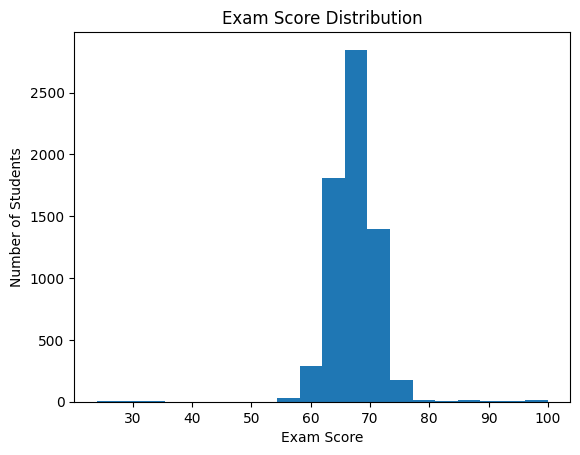

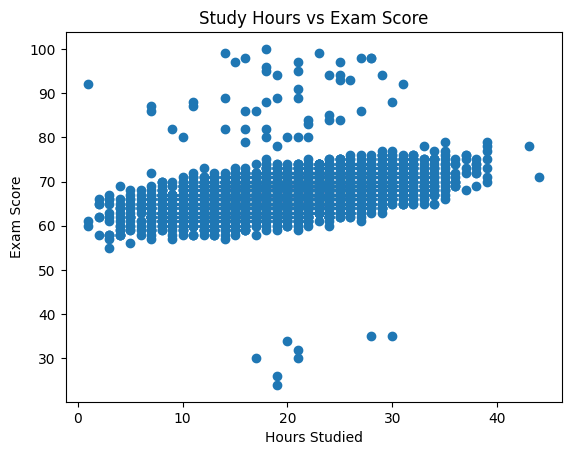

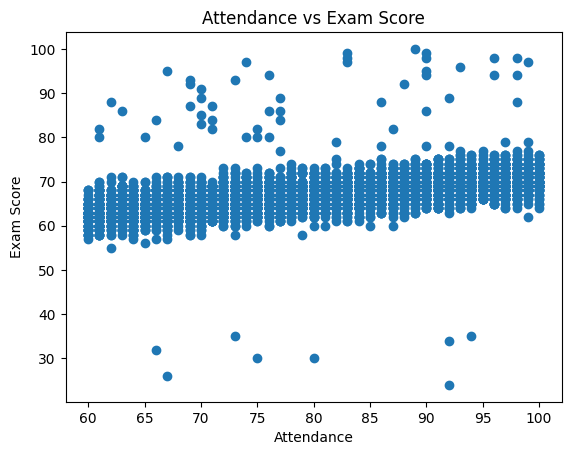

In [10]:
# =====================================================
# STEP 4: DATA VISUALIZATION
# =====================================================
# Visualize relationships between variables.

import matplotlib.pyplot as plt

# 1. Distribution of Exam Score values
plt.hist(data['Exam_Score'], bins=20)

plt.title("Exam Score Distribution")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")

plt.show()


# 2. Study Hours vs Exam Score

plt.scatter(data['Hours_Studied'], data['Exam_Score'])

plt.title("Study Hours vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.show()


# 3. Attendance vs Exam Score

plt.scatter(data['Attendance'], data['Exam_Score'])

plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance")
plt.ylabel("Exam Score")

plt.show()

In [11]:
# =====================================================
# STEP 5: DATA PREPARATION
# =====================================================
# Machine learning models cannot understand text values.
# Therefore we convert categorical columns into numbers.

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

# Convert categorical columns
data['Gender'] = encoder.fit_transform(data['Gender'])
data['Parental_Involvement'] = encoder.fit_transform(data['Parental_Involvement'])
data['Access_to_Resources'] = encoder.fit_transform(data['Access_to_Resources'])
data['Extracurricular_Activities'] = encoder.fit_transform(data['Extracurricular_Activities'])
data['Motivation_Level'] = encoder.fit_transform(data['Motivation_Level'])
data['Internet_Access'] = encoder.fit_transform(data['Internet_Access'])
data['Family_Income'] = encoder.fit_transform(data['Family_Income'])
data['Teacher_Quality'] = encoder.fit_transform(data['Teacher_Quality'])
data['School_Type'] = encoder.fit_transform(data['School_Type'])
data['Peer_Influence'] = encoder.fit_transform(data['Peer_Influence'])
data['Learning_Disabilities'] = encoder.fit_transform(data['Learning_Disabilities'])
data['Parental_Education_Level'] = encoder.fit_transform(data['Parental_Education_Level'])

# Display updated dataset
print("Dataset after converting categorical values:")
print(data.head(7))

Dataset after converting categorical values:
   Id  Hours_Studied  Attendance  Parental_Involvement  Access_to_Resources  \
0   1             23          84                     1                    0   
1   2             19          64                     1                    2   
2   3             24          98                     2                    2   
3   4             29          89                     1                    2   
4   5             19          92                     2                    2   
5   6             19          88                     2                    2   
6   7             29          84                     2                    1   

   Extracurricular_Activities  Sleep_Hours  Previous_Scores  Motivation_Level  \
0                           0            7               73                 1   
1                           0            8               59                 1   
2                           1            7               91                 2  

In [12]:
# =====================================================
# STEP 6: REMOVE UNNECESSARY COLUMNS
# =====================================================
# 'Id' is just an identifier and does not affect prediction.

# Drop unnecessary columns
data = data.drop(['Id'], axis=1)

print("Columns after removing unnecessary columns:")
print(data.columns)

Columns after removing unnecessary columns:
Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Gender', 'Exam_Score'],
      dtype='str')


In [13]:
# =====================================================
# STEP 7: TRAIN-TEST SPLIT
# =====================================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Features (Recommended Multiple Features)
X = data[[
    'Hours_Studied',
    'Attendance',
    'Previous_Scores',
    'Sleep_Hours',
    'Tutoring_Sessions',
    'Physical_Activity'
]]

# Target
y = data['Exam_Score']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)


Training data size: (5285, 6)
Testing data size: (1322, 6)


In [14]:
# =====================================================
# STEP 8: MODEL TRAINING
# =====================================================

model = LinearRegression()
model.fit(X_train, y_train)

print("Model training completed.")


Model training completed.


In [15]:
# =====================================================
# STEP 9: PREDICT RESULTS
# =====================================================

y_pred = model.predict(X_test)

print("Sample predicted Exam Score values:")
print(y_pred[:10])

Sample predicted Exam Score values:
[66.07332336 67.20546978 68.38524963 66.76522995 65.63243881 67.97556548
 70.09975329 67.30011296 68.88920168 67.92827413]


In [16]:
# =====================================================
# STEP 10: MODEL EVALUATION
# =====================================================

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 6.966478303058493
R2 Score: 0.5738888372492275
